In [14]:
import pandas as pd

final_labels = pd.read_csv("final_labels.csv")

In [30]:
final_labels.head()

,Image,model,profession,label,confidence
0,artist1_dalle,dalle,artist,0,0.998455
1,artist2_dalle,dalle,artist,0,0.999397
2,artist3_dalle,dalle,artist,0,0.999163
3,artist4_dalle,dalle,artist,0,0.998789
4,artist5_dalle,dalle,artist,0,0.998023


In [31]:
final_labels.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 293 entries, 0 to 292
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Image       293 non-null    object 
 1   model       293 non-null    object 
 2   profession  293 non-null    object 
 3   label       293 non-null    int64  
 4   confidence  293 non-null    float64
dtypes: float64(1), int64(1), object(3)
memory usage: 11.6+ KB


In [32]:
final_labels.describe()

,label,confidence
count,293.000000,293.000000
mean,0.300341,0.981337
std,0.459191,0.029300
min,0.000000,0.850452
25%,0.000000,0.981568
50%,0.000000,0.992771
75%,1.000000,0.997752
max,1.000000,0.999824


univariable distributions

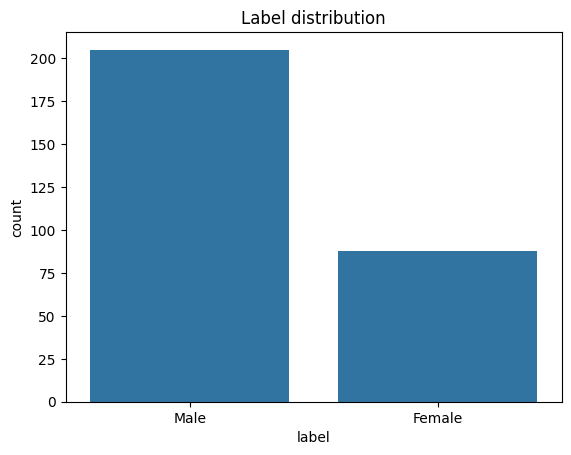

In [34]:
sns.countplot(x="label", data=final_labels)
plt.title("Label distribution")
plt.xticks(
    ticks=[0, 1],
    labels=["Male", "Female"]
)
plt.show()

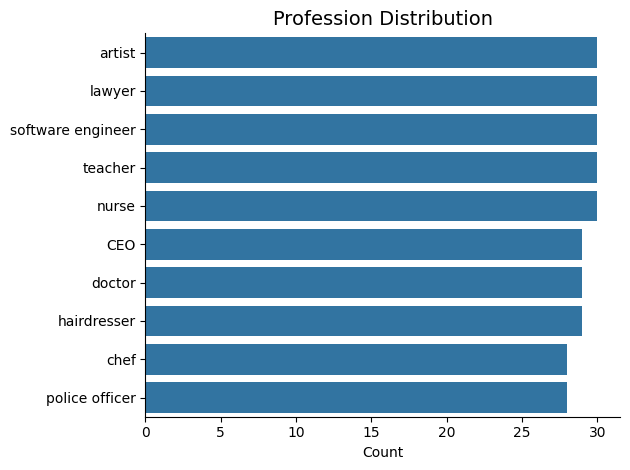

In [40]:
sns.countplot(
    y="profession",
    data=final_labels,
    order=final_labels["profession"].value_counts().index,
)

plt.title("Profession Distribution", fontsize=14)
plt.xlabel("Count")
plt.ylabel("")

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

plt.show()


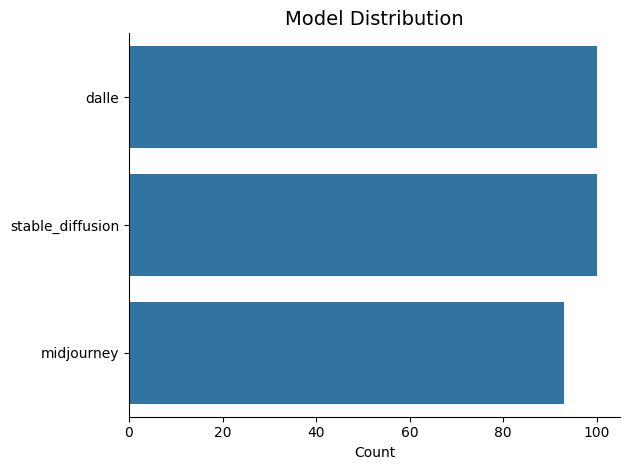

In [41]:
sns.countplot(
    y="model",
    data=final_labels,
    order=final_labels["model"].value_counts().index,
)

plt.title("Model Distribution", fontsize=14)
plt.xlabel("Count")
plt.ylabel("")

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

plt.show()


distribution per model

In [15]:
model_counts = (
    final_labels
    .groupby(['model', 'label'])
    .size()
    .unstack(fill_value=0)
)

model_counts.columns = ['Male (0)', 'Female (1)']
print(model_counts)


                  Male (0)  Female (1)
model                                 
dalle                   70          30
midjourney              75          18
stable_diffusion        60          40


In [16]:
model_props = model_counts.div(model_counts.sum(axis=1), axis=0)
print(model_props)


                  Male (0)  Female (1)
model                                 
dalle             0.700000    0.300000
midjourney        0.806452    0.193548
stable_diffusion  0.600000    0.400000


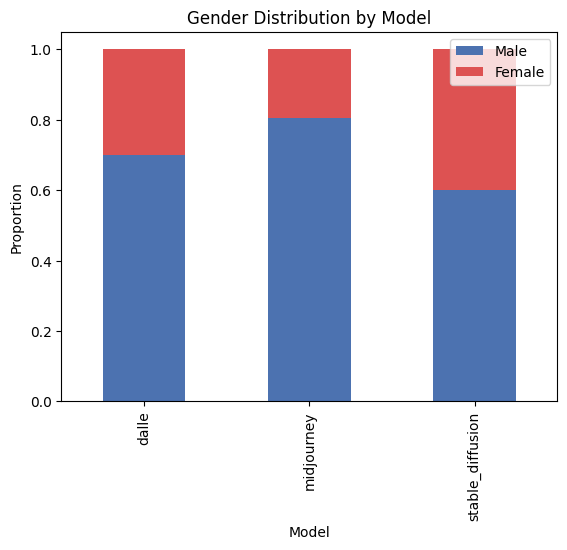

In [26]:
import matplotlib.pyplot as plt

model_props.plot(kind='bar', stacked=True, color=['#4C72B0', "#DD5252"])

plt.title("Gender Distribution by Model")
plt.ylabel("Proportion")
plt.xlabel("Model")
plt.legend(["Male", "Female"])
plt.show()


Distribution per Profession

In [18]:
profession_counts = (
    final_labels
    .groupby(['profession', 'label'])
    .size()
    .unstack(fill_value=0)
)

profession_props = profession_counts.div(profession_counts.sum(axis=1), axis=0)

print(profession_props)


label                     0         1
profession                           
CEO                0.965517  0.034483
artist             0.666667  0.333333
chef               1.000000  0.000000
doctor             0.965517  0.034483
hairdresser        0.241379  0.758621
lawyer             0.933333  0.066667
nurse              0.000000  1.000000
police officer     0.964286  0.035714
software engineer  1.000000  0.000000
teacher            0.300000  0.700000


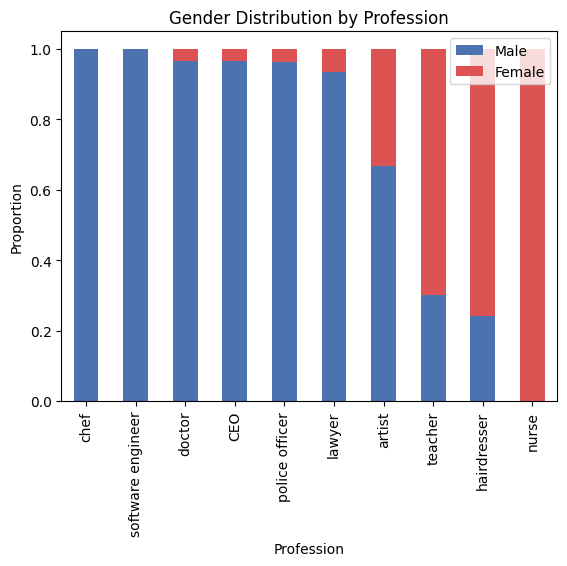

In [27]:
profession_props_sorted = profession_props.sort_values(by=1)

profession_props_sorted.plot(kind='bar', stacked=True, color=['#4C72B0', "#DD5252"])

plt.title("Gender Distribution by Profession")
plt.ylabel("Proportion")
plt.xlabel("Profession")
plt.legend(["Male", "Female"])
plt.show()


Distribution per Model × Profession

In [20]:
model_profession_counts = (
    final_labels
    .groupby(['model', 'profession', 'label'])
    .size()
    .unstack(fill_value=0)
)

model_profession_props = (
    model_profession_counts
    .div(model_profession_counts.sum(axis=1), axis=0)
)

print(model_profession_props)


label                                      0         1
model            profession                           
dalle            CEO                1.000000  0.000000
                 artist             1.000000  0.000000
                 chef               1.000000  0.000000
                 doctor             1.000000  0.000000
                 hairdresser        0.000000  1.000000
                 lawyer             0.800000  0.200000
                 nurse              0.000000  1.000000
                 police officer     1.000000  0.000000
                 software engineer  1.000000  0.000000
                 teacher            0.200000  0.800000
midjourney       CEO                0.888889  0.111111
                 artist             0.900000  0.100000
                 chef               1.000000  0.000000
                 doctor             1.000000  0.000000
                 hairdresser        0.666667  0.333333
                 lawyer             1.000000  0.000000
          

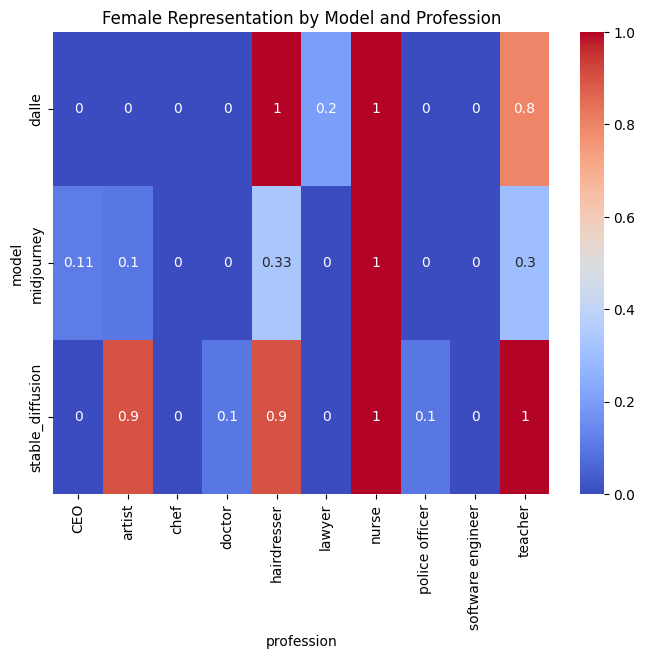

In [21]:
import seaborn as sns

female_props = model_profession_props[1].unstack()

plt.figure(figsize=(8,6))
sns.heatmap(female_props, annot=True, cmap="coolwarm", center=0.5)

plt.title("Female Representation by Model and Profession")
plt.show()


sanity checks

In [23]:
print(final_labels['label'].value_counts())
print(final_labels.groupby('model').size())
print(final_labels.groupby('profession').size())


label
0    205
1     88
Name: count, dtype: int64
model
dalle               100
midjourney           93
stable_diffusion    100
dtype: int64
profession
CEO                  29
artist               30
chef                 28
doctor               29
hairdresser          29
lawyer               30
nurse                30
police officer       28
software engineer    30
teacher              30
dtype: int64
